In [3]:
# NumPy is used for numerical calculations such as arrays, math operations,
# and handling large sets of numbers efficiently
import numpy as np

# Pandas is used for working with data in table form (rows and columns),
# similar to Excel sheets. It helps in reading, analyzing, and manipulating data.
import pandas as pd

# Matplotlib is used for plotting graphs and visualizing data
# (line plots, bar charts, scatter plots, etc.)
import matplotlib.pyplot as plt

In [4]:
# Read the CSV file named 'Lane4_NGSM.csv'
# and store the data in a DataFrame (table-like structure)
# The variable name 'lane4_data' clearly indicates
# that this data belongs to Lane 4 of the NGSM dataset
lane4_data = pd.read_csv('Lane4_NGSM.csv')
# Display the entire dataset in the notebook
lane4_data

,Vehicle_ID,Frame_ID,Local_X,Local_Y,v_Vel,Time
0,13,132,12.686081,19.802246,6.705600,12.801
1,13,133,12.687605,20.747736,6.705600,12.901
2,13,134,12.628778,21.565210,6.705600,13.001
3,13,135,12.613538,22.235770,6.705600,13.101
4,13,136,12.598298,22.906330,6.705600,13.201
...,...,...,...,...,...,...
606008,1751,7838,12.664440,498.971621,2.225040,2464.703
606009,1751,7839,12.665659,499.171265,2.237232,2464.803
606010,1751,7840,12.666878,499.343477,2.237232,2464.903
606011,1751,7841,12.669012,499.648582,2.237232,2465.003


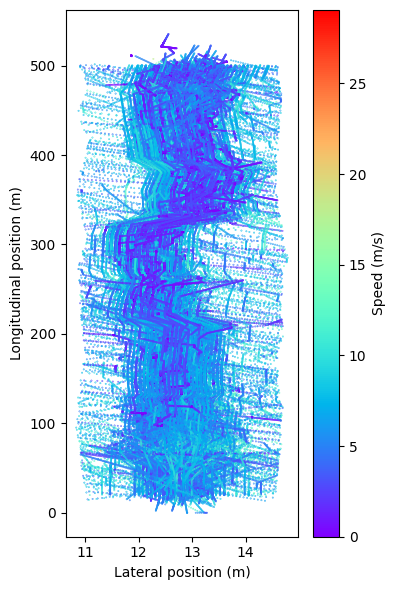

In [5]:
# Create a new figure for plotting
# figsize controls the size of the plot (width, height in inches)
# dpi controls the image quality (higher = clearer image)
plt.figure(figsize=(4, 6))

# Create a scatter plot:
# Local_X  -> x-axis (lateral position)
# Local_Y  -> y-axis (longitudinal position)
# v_Vel    -> color of each point represents vehicle speed
# s        -> size of each point
scatter_plot = plt.scatter(
    lane4_data['Local_X'],
    lane4_data['Local_Y'],
    c=lane4_data['v_Vel'],
    s=0.1,
    cmap='rainbow'
)


# Label the x-axis and y-axis
plt.xlabel('Lateral position (m)')
plt.ylabel('Longitudinal position (m)')

# Add a colorbar to show what the colors mean
colorbar = plt.colorbar(scatter_plot)
colorbar.set_label('Speed (m/s)')


# Adjust layout so labels do not overlap
plt.tight_layout()

# Save the figure as an image file
plt.savefig('Lane_4_Trajectory_2D.png')

# Display the plot on the screen
plt.show()


In [6]:
# Find the starting and ending position of the road in the Y direction
road_length_start = lane4_data['Local_Y'].min()
road_length_end   = lane4_data['Local_Y'].max()

In [7]:
# Find the starting and ending time of the vehicle trajectories
time_start = lane4_data['Time'].min()
time_end   = lane4_data['Time'].max()

In [8]:
#Print the results in a clear and readable way
print("Road length starts at:", road_length_start, "and ends at:", road_length_end)
print("Trajectory time starts at:", time_start, "and ends at:", time_end)

Road length starts at: 0.0 and ends at: 535.4333208
Trajectory time starts at: 10.201 and ends at: 2470.203


In [9]:
lane4_data.columns

Index(['Vehicle_ID', 'Frame_ID', 'Local_X', 'Local_Y', 'v_Vel', 'Time'], dtype='object')

Virtual Detector Setup

In [10]:
Detector_length = 40 # m
Detector_time = 40 # sec

In [11]:
# ---------------------------------------------------------
# Define starting positions of virtual detectors along the road
# np.arange(start, stop, step) creates equally spaced values
# ---------------------------------------------------------

# Starting x-positions (in meters) of detectors along the road
detector_y_start_positions = np.arange(
    20,                         # start position (meters)
    520 - Detector_length,      # last possible start position
    Detector_length             # distance between detectors
)

# Ending x-positions of detectors
# Each detector ends after 'Detector_length' meters
detector_y_end_positions = detector_y_start_positions + Detector_length


# ---------------------------------------------------------
# Define starting times of virtual detectors
# ---------------------------------------------------------

# Starting times (in seconds) when detectors begin collecting data
detector_time_start_points = np.arange(
    30,                         # start time (seconds)
    2440 - Detector_time,       # last possible start time
    Detector_time               # time interval between detectors
)

# Ending times of detectors
# Each detector operates for 'Detector_time' seconds
detector_time_end_points = detector_time_start_points + Detector_time
 


In [12]:
detector_y_start_positions

array([ 20,  60, 100, 140, 180, 220, 260, 300, 340, 380, 420, 460])

In [13]:
# Print all starting x-positions of detectors
print("Detector Y start positions:", detector_y_start_positions)

# Print all ending x-positions of detectors
print("Detector Y end positions:  ", detector_y_end_positions)

# Print only the first 5 and last 3 detector start times (to avoid long output)
print("Detector start times:", detector_time_start_points[:5], "...", detector_time_start_points[-3:])

# Print only the first 5 and last 3 detector end times
print("Detector end times:  ", detector_time_end_points[:5], "...", detector_time_end_points[-3:])


Detector Y start positions: [ 20  60 100 140 180 220 260 300 340 380 420 460]
Detector Y end positions:   [ 60 100 140 180 220 260 300 340 380 420 460 500]
Detector start times: [ 30  70 110 150 190] ... [2310 2350 2390]
Detector end times:   [ 70 110 150 190 230] ... [2350 2390 2430]


In [14]:
# Create a DataFrame that stores all detector information
# Each row represents one virtual detector in space and time
detector_table = pd.DataFrame({

    # Repeat each X-start position for all time intervals
    "Y_start": np.repeat(detector_y_start_positions, len(detector_time_start_points)),

    # Repeat each X-end position for all time intervals
    "Y_end": np.repeat(detector_y_end_positions, len(detector_time_start_points)),

    # Tile (repeat in sequence) all time start points for each X position
    "T_start": np.tile(detector_time_start_points, len(detector_y_start_positions)),

    # Tile (repeat in sequence) all time end points
    "T_end": np.tile(detector_time_end_points, len(detector_y_start_positions))
})



In [15]:
np.tile(detector_time_start_points, len(detector_y_start_positions))


array([  30,   70,  110,  150,  190,  230,  270,  310,  350,  390,  430,
        470,  510,  550,  590,  630,  670,  710,  750,  790,  830,  870,
        910,  950,  990, 1030, 1070, 1110, 1150, 1190, 1230, 1270, 1310,
       1350, 1390, 1430, 1470, 1510, 1550, 1590, 1630, 1670, 1710, 1750,
       1790, 1830, 1870, 1910, 1950, 1990, 2030, 2070, 2110, 2150, 2190,
       2230, 2270, 2310, 2350, 2390,   30,   70,  110,  150,  190,  230,
        270,  310,  350,  390,  430,  470,  510,  550,  590,  630,  670,
        710,  750,  790,  830,  870,  910,  950,  990, 1030, 1070, 1110,
       1150, 1190, 1230, 1270, 1310, 1350, 1390, 1430, 1470, 1510, 1550,
       1590, 1630, 1670, 1710, 1750, 1790, 1830, 1870, 1910, 1950, 1990,
       2030, 2070, 2110, 2150, 2190, 2230, 2270, 2310, 2350, 2390,   30,
         70,  110,  150,  190,  230,  270,  310,  350,  390,  430,  470,
        510,  550,  590,  630,  670,  710,  750,  790,  830,  870,  910,
        950,  990, 1030, 1070, 1110, 1150, 1190, 12

In [16]:
# Assign a unique detector ID for each X-location
# Detectors with the same X_start get the same ID
detector_table["detector_id"] = (
    pd.factorize(detector_table["Y_start"])[0] + 1
)
# Display the first 5 rows of the detector table
detector_table
#.head()


,Y_start,Y_end,T_start,T_end,detector_id
0,20,60,30,70,1
1,20,60,70,110,1
2,20,60,110,150,1
3,20,60,150,190,1
4,20,60,190,230,1
...,...,...,...,...,...
715,460,500,2230,2270,12
716,460,500,2270,2310,12
717,460,500,2310,2350,12
718,460,500,2350,2390,12


Calculation of Variables

In [17]:
from tqdm import tqdm

# ------------------------------------------------------------
# Step 1: Create empty result columns in detector_table
# ------------------------------------------------------------
detector_table['Num_vehicles']   = np.nan   # number of vehicles
detector_table['Total_distance'] = np.nan   # total distance traveled
detector_table['Total_time']     = np.nan   # total time spent
display(detector_table.head())

# ------------------------------------------------------------
# Step 2: Loop over each detector
# ------------------------------------------------------------
#for detector_index in tqdm(range(2)):
for detector_index in tqdm(range(len(detector_table))):

    # Detector spatial limits (longitudinal direction)
    y_start = detector_table.loc[detector_index, 'Y_start']
    y_end   = detector_table.loc[detector_index, 'Y_end']

    # Detector time limits
    t_start = detector_table.loc[detector_index, 'T_start']
    t_end   = detector_table.loc[detector_index, 'T_end']


    # --------------------------------------------------------
    # Step 3: Extract vehicle data inside detector window
    # --------------------------------------------------------
    detector_window_data = lane4_data[
        (lane4_data['Local_Y'] >= y_start) &
        (lane4_data['Local_Y'] <= y_end) &
        (lane4_data['Time']    >= t_start) &
        (lane4_data['Time']    <= t_end)
    ].copy()


    # --------------------------------------------------------
    # Step 4: If no vehicle is present, store zeros
    # --------------------------------------------------------
    if detector_window_data.empty:

        detector_table.loc[detector_index, 'Num_vehicles']   = 0
        detector_table.loc[detector_index, 'Total_distance'] = 0.0
        detector_table.loc[detector_index, 'Total_time']     = 0.0

        continue


    # --------------------------------------------------------
    # Step 5: Compute distance and time for each vehicle
    # --------------------------------------------------------
    vehicle_ids = detector_window_data['Vehicle_ID'].unique()

    total_distance = 0.0
    total_time = 0.0

    for vehicle_id in vehicle_ids:

        vehicle_data = detector_window_data[
            detector_window_data['Vehicle_ID'] == vehicle_id
        ].sort_values('Time')

        # Distance traveled by this vehicle inside detector
        if len(vehicle_data) > 1:
            distance = vehicle_data['Local_Y'].max() - vehicle_data['Local_Y'].min()
        else:
            distance = 0.0

        # Time spent by this vehicle inside detector
        if len(vehicle_data) > 1:
            time_spent = vehicle_data['Time'].max() - vehicle_data['Time'].min()
        else:
            time_spent = 0.0

        total_distance += distance
        total_time     += time_spent


    # --------------------------------------------------------
    # Step 6: Store results for this detector
    # --------------------------------------------------------
    detector_table.loc[detector_index, 'Num_vehicles']   = len(vehicle_ids)
    detector_table.loc[detector_index, 'Total_distance'] = total_distance
    detector_table.loc[detector_index, 'Total_time']     = total_time


# ------------------------------------------------------------
# Step 7: Display first few rows of detector results
# ------------------------------------------------------------
#display(detector_table.head())


,Y_start,Y_end,T_start,T_end,detector_id,Num_vehicles,Total_distance,Total_time
0,20,60,30,70,1,NaN,NaN,NaN
1,20,60,70,110,1,NaN,NaN,NaN
2,20,60,110,150,1,NaN,NaN,NaN
3,20,60,150,190,1,NaN,NaN,NaN
4,20,60,190,230,1,NaN,NaN,NaN


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:16<00:00, 44.38it/s]


In [20]:
# ------------------------------------------------------------
# Step 1: Compute traffic density
# Density = total vehicle time / (detector length × detector time)
# The factor 1000 converts meters to kilometers
# ------------------------------------------------------------
detector_table['Density'] = (
    detector_table['Total_time'] * 1000
) / (Detector_length * Detector_time)


# ------------------------------------------------------------
# Step 2: Compute traffic flow
# Flow = total vehicle distance / (detector length × detector time)
# The factor 3600 converts seconds to hours
# ------------------------------------------------------------
detector_table['Flow'] = (
    detector_table['Total_distance'] * 3600
) / (Detector_length * Detector_time)


# ------------------------------------------------------------
# Step 3: Compute average speed
# Speed = Flow / Density
# ------------------------------------------------------------
detector_table['Speed'] = (
    detector_table['Flow'] / detector_table['Density']
)


# ------------------------------------------------------------
# Step 4: Display the first 10 rows of results
# ------------------------------------------------------------
detector_table.head(10)


,Y_start,Y_end,T_start,T_end,detector_id,Num_vehicles,Total_distance,Total_time,Density,Flow,Speed
0,20,60,30,70,1,15.0,442.814354,117.0,73.1250,996.332297,13.625057
1,20,60,70,110,1,18.0,586.804922,67.3,42.0625,1320.311075,31.389268
2,20,60,110,150,1,NaN,NaN,NaN,NaN,NaN,NaN
3,20,60,150,190,1,NaN,NaN,NaN,NaN,NaN,NaN
4,20,60,190,230,1,NaN,NaN,NaN,NaN,NaN,NaN
5,20,60,230,270,1,NaN,NaN,NaN,NaN,NaN,NaN
6,20,60,270,310,1,NaN,NaN,NaN,NaN,NaN,NaN
7,20,60,310,350,1,NaN,NaN,NaN,NaN,NaN,NaN
8,20,60,350,390,1,NaN,NaN,NaN,NaN,NaN,NaN
9,20,60,390,430,1,NaN,NaN,NaN,NaN,NaN,NaN


Macroscopic Variable Relation Plots

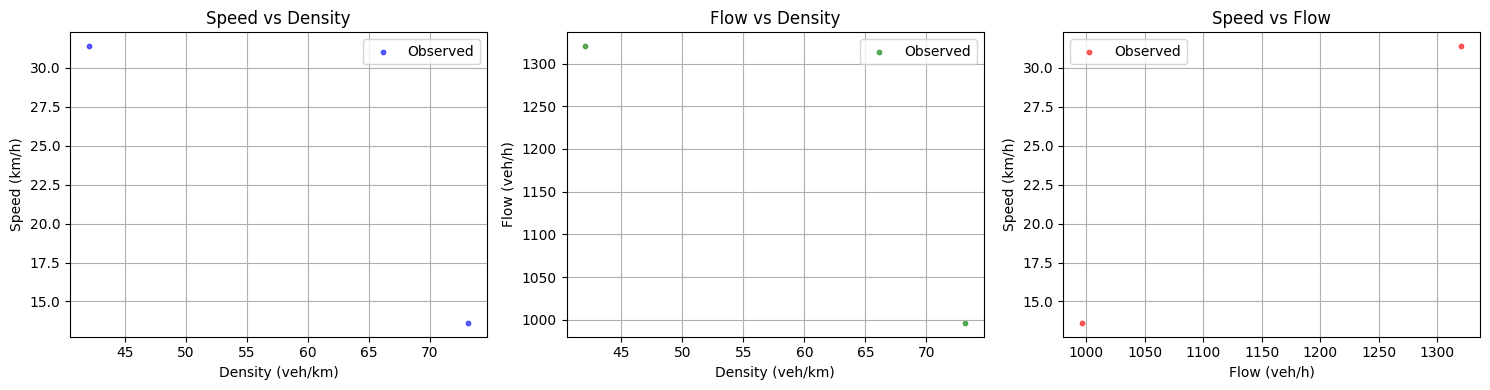

In [21]:
# ------------------------------------------------------------
# Step 1: Create a wide figure to place 3 plots side by side
# ------------------------------------------------------------
plt.figure(figsize=(15, 4))


# ------------------------------------------------------------
# Plot 1: Speed vs Density
# ------------------------------------------------------------
plt.subplot(1, 3, 1)   # 1 row, 3 columns, plot 1

plt.scatter(
    detector_table['Density'],     # x-axis: density
    detector_table['Speed'],       # y-axis: speed
    s=10,                          # size of points
    c='blue',
    alpha=0.6,
    label='Observed'
)

plt.xlabel('Density (veh/km)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Density')
plt.grid(True)
plt.legend()


# ------------------------------------------------------------
# Plot 2: Flow vs Density
# ------------------------------------------------------------
plt.subplot(1, 3, 2)   # 1 row, 3 columns, plot 2

plt.scatter(
    detector_table['Density'],     # x-axis: density
    detector_table['Flow'],        # y-axis: flow
    s=10,
    c='green',
    alpha=0.6,
    label='Observed'
)

plt.xlabel('Density (veh/km)')
plt.ylabel('Flow (veh/h)')
plt.title('Flow vs Density')
plt.grid(True)
plt.legend()


# ------------------------------------------------------------
# Plot 3: Speed vs Flow
# ------------------------------------------------------------
plt.subplot(1, 3, 3)   # 1 row, 3 columns, plot 3

plt.scatter(
    detector_table['Flow'],        # x-axis: flow
    detector_table['Speed'],       # y-axis: speed
    s=10,
    c='red',
    alpha=0.6,
    label='Observed'
)

plt.xlabel('Flow (veh/h)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Flow')
plt.grid(True)
plt.legend()


# ------------------------------------------------------------
# Final adjustments, save, and show
# ------------------------------------------------------------
plt.tight_layout()   # avoid overlapping labels
plt.savefig('Lane_4_Fundamental_Relation.png')
plt.show()
